# Strait of Hormuz: Global Oil Flows, Exposure, and Disruption Risk

The Strait of Hormuz is one of the most critical oil transit chokepoints in the global energy system. Roughly one-fifth of the world’s oil supply flows through this narrow passage, making it a key vulnerability in global energy security.

Any disruption to flows through Hormuz has the potential to trigger significant supply shocks, price volatility, and broader macroeconomic consequences.

This data story answers three key questions:
<div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px;">
1. Where do oil flows through the Strait of Hormuz originate, and where do they go?<br> 
2. Which countries are most exposed to Hormuz-dependent oil flows?<br>  
3. What is the impact on global oil supply if a disruption occurs?<br>
</div>

---
<span style="color:gray;">
<b>Note:</b>
To address these questions, I construct a dataset using U.S. Energy Information Administration (EIA) data on origin–destination flows and country-level exposure, and use it to analyze the structure, vulnerability, and resilience of the global oil system. The analysis focuses on 2024 as the most recent full year of available data, providing a consistent and complete snapshot of global oil flows through the Strait of Hormuz. More recent data from Q1 2025 is not included, but follows a similar pattern, reinforcing the stability of the observed flow structure. By combining flow data (network visualization), exposure mapping (choropleth map), and a shock scenario (horizontal stacked decomposition bar), this data story evaluates the systemic importance and vulnerability of the Strait of Hormuz within the global oil market.</span>

<span style="font-size:12px;">**Values are in million barrels per day (mb/d).**</span>

---

#### 1. Global Oil Flows Through Strait of Hormuz

**This chart maps the origin and destination of oil flows transiting the Strait of Hormuz.**

<u>Key Insights<br>
<div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px;">
- Asia dominates Hormuz flows<br>
- Supply is concentrated in Gulf exporters<br>
- The strait is a critical chokepoint<br>
</div>

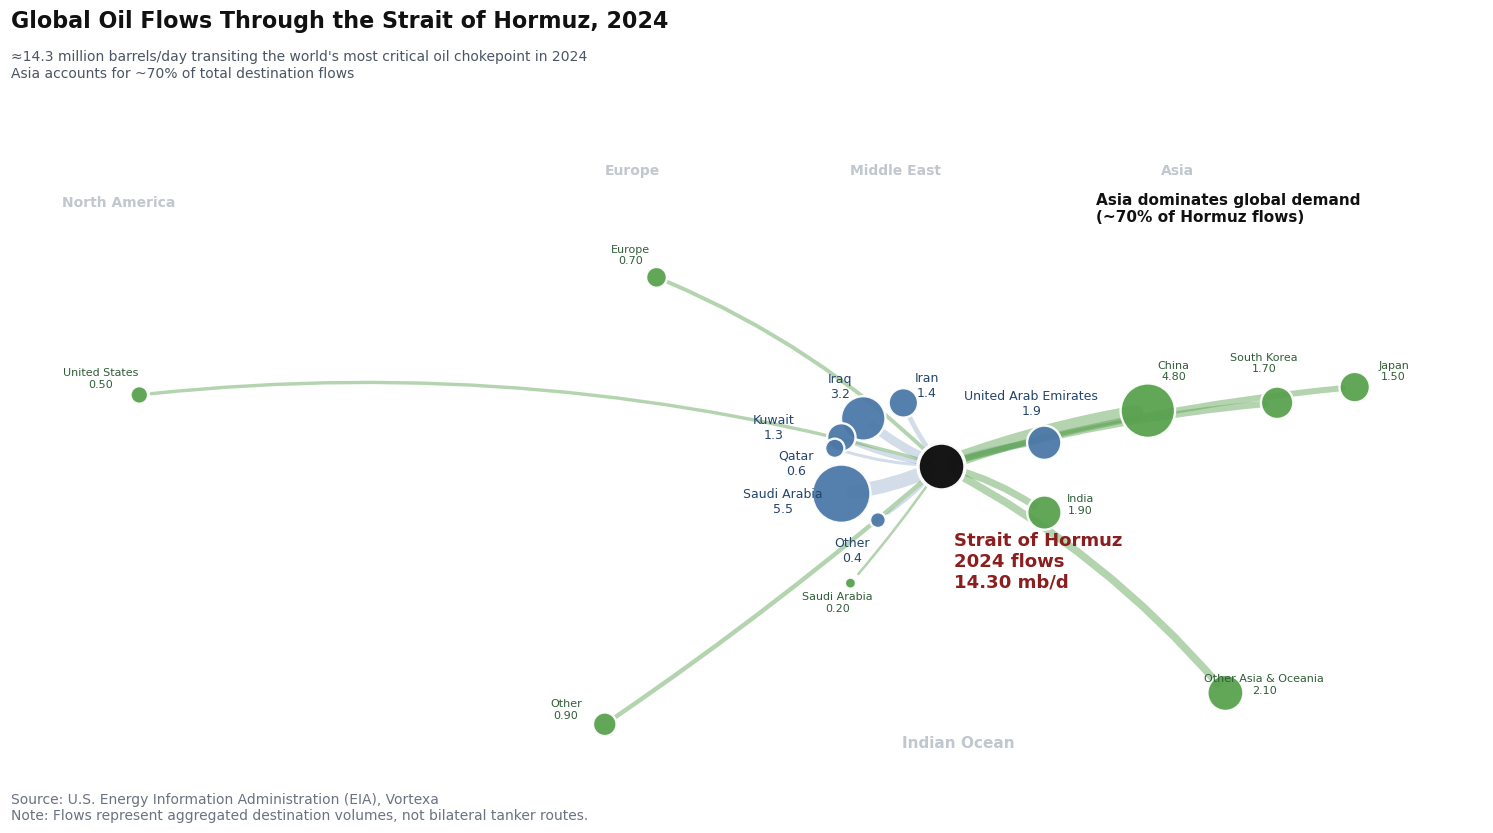

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ============================================================
# Oil Flows Through the Strait of Hormuz, 2024
# Gulf exporters are automatically spread around Hormuz
# ============================================================

# -----------------------------
# 1. Input data (2024)
# -----------------------------
origins = {
    "Saudi Arabia": 5.5,
    "Iraq": 3.2,
    "United Arab Emirates": 1.9,
    "Iran": 1.4,
    "Kuwait": 1.3,
    "Qatar": 0.6,
    "Other": 0.4,
}

destinations = {
    "China": 4.8,
    "India": 1.9,
    "South Korea": 1.7,
    "Japan": 1.5,
    "Other Asia": 2.1,
    "Europe": 0.7,
    "United States": 0.5,
    "Saudi Arabia": 0.2,
    "Other": 0.9,
}

# -----------------------------
# 2. Build graph
# -----------------------------

G = nx.DiGraph()

hormuz_node = "Strait of Hormuz"
G.add_node(hormuz_node, node_type="chokepoint", volume=sum(origins.values()))

for country, flow in origins.items():
    G.add_node(country, node_type="origin", volume=flow)
    G.add_edge(country, hormuz_node, weight=flow)

for country, flow in destinations.items():
    node_name = f"{country} (dest)" if country in origins else country
    G.add_node(node_name, node_type="destination", volume=flow, label=country)
    G.add_edge(hormuz_node, node_name, weight=flow)


# -----------------------------
# 3. Manual positions
# -----------------------------

pos = {
    # Hormuz
    "Strait of Hormuz": (0.70, 0.39),

    # Destinations
    "United States": (0.08, 0.48),
    "Europe": (0.48, 0.63),
    "Saudi Arabia (dest)": (0.63, 0.24),
    "China": (0.86, 0.46),
    "India": (0.78, 0.33),
    "South Korea": (0.96, 0.47),
    "Japan": (1.02, 0.49),
    "Other Asia": (0.92, 0.10),
    "Other (dest)": (0.44, 0.06),
}

# -----------------------------
# 4. Automatically spread Gulf exporters
# -----------------------------

gulf_exporters = [
    "Iraq",
    "Iran",
    "United Arab Emirates",
    "Saudi Arabia",
    "Qatar",
    "Other",
    "Kuwait",
]

hx, hy = pos[hormuz_node]

radius = 0.085
angles_deg = [135, 110, 20, 205, 165, 235, 155]  # tweak these if desired

for node, angle in zip(gulf_exporters, angles_deg):
    rad = np.radians(angle)
    pos[node] = (
        hx + radius * np.cos(rad),
        hy + radius * np.sin(rad)
    )

# -----------------------------
# 5. Style settings
# -----------------------------
origin_color = "#4c78a8"
destination_color = "#59a14f"
hormuz_color = "#111111"

bg_color = "#ffffff"
text_dark = "#111111"
text_muted = "#6b7280"
region_color = "#9aa3af"

fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# -----------------------------
# 6. Background grid / map frame
# -----------------------------

ax.text(0.02, 0.72, "North America", fontsize=10, color="#c0c7cf", weight="bold")
ax.text(0.44, 0.76, "Europe", fontsize=10, color="#c0c7cf", weight="bold")
ax.text(0.63, 0.76, "Middle East", fontsize=10, color="#c0c7cf", weight="bold")
ax.text(0.87, 0.76, "Asia", fontsize=10, color="#c0c7cf", weight="bold")
ax.text(0.67, 0.03, "Indian Ocean", fontsize=11, color="#c0c7cf", weight="bold")

# -----------------------------
# 7. Draw edges
# -----------------------------

origin_edges = [(u, v) for u, v in G.edges() if v == hormuz_node]
dest_edges = [(u, v) for u, v in G.edges() if u == hormuz_node]


# Origin -> Hormuz

for u, v in origin_edges:
    flow = G[u][v]["weight"]
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color=origin_color,
        width=1.2 + flow * 1.6,
        alpha=0.25,
        arrows=True,
        arrowstyle="-",
        connectionstyle="arc3,rad=0.08",
    )

# Hormuz -> Destination
for u, v in dest_edges:
    flow = G[u][v]["weight"]

    rad = 0.0
    if v in ["United States", "Europe"]:
        rad = 0.10
    elif v in ["China", "South Korea", "Japan"]:
        rad = -0.05
    elif v in ["Other Asia", "India"]:
        rad = -0.10
    elif v in ["Other (dest)", "Saudi Arabia (dest)"]:
        rad = -0.03

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color=destination_color,
        width=1.5 + flow * 1.9,
        alpha=0.45,
        arrows=True,
        arrowstyle="-",
        connectionstyle=f"arc3,rad={rad}",
    )

# -----------------------------
# 8. Draw nodes
# -----------------------------

origin_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "origin"]
destination_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "destination"]

origin_sizes = [origins[n] * 320 for n in origin_nodes]
destination_sizes = [G.nodes[n]["volume"] * 320 for n in destination_nodes]
hormuz_size = sum(origins.values()) * 80

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=origin_nodes,
    node_size=origin_sizes,
    node_color=origin_color,
    edgecolors="white",
    linewidths=1.7,
    alpha=0.95,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=destination_nodes,
    node_size=destination_sizes,
    node_color=destination_color,
    edgecolors="white",
    linewidths=1.7,
    alpha=0.95,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=[hormuz_node],
    node_size=hormuz_size,
    node_color="#111111",
    edgecolors="white",
    linewidths=2.5,
    alpha=0.98,
    ax=ax,
)

# -----------------------------
# 9. Manual label offsets
#    Edit these numbers to fine-tune label placement
#    (dx, dy): +x = right, -x = left, +y = up, -y = down
# -----------------------------

label_offsets = {
    # exporters
    "Saudi Arabia": (-0.045, -0.010),
    "Iraq": (-0.018, 0.040),
    "United Arab Emirates": (-0.010, 0.05),
    "Iran": (0.018, 0.022),
    "Kuwait": (-0.052, 0.012),
    "Qatar": (-0.030, -0.020),
    "Other": (-0.020, -0.040),

    # destinations
    "China": (0.020, 0.050),
    "India": (0.028, 0.010),
    "South Korea": (-0.010, 0.050),
    "Japan": (0.030, 0.020),
    "Other Asia": (0.030, 0.010),
    "Europe": (-0.020, 0.028),
    "United States": (-0.030, 0.020),
    "Saudi Arabia (dest)": (-0.010, - 0.025),
    "Other (dest)": (-0.030, 0.018),
}

# -----------------------------
# 10. Draw labels WITHOUT boxes
# -----------------------------
for n in origin_nodes:
    x, y = pos[n]
    dx, dy = label_offsets.get(n, (0.01, 0.01))
    val = origins[n]

    ax.text(
        x + dx,
        y + dy,
        f"{n}\n{val:.1f}",
        fontsize=9,
        ha="center",
        va="center",
        color="#24456b",
        zorder=10,
    )

for n in destination_nodes:
    x, y = pos[n]
    dx, dy = label_offsets.get(n, (0.01, 0.01))
    label = G.nodes[n].get("label", n)
    val = G.nodes[n]["volume"]

    if label == "Other Asia":
        label = "Other Asia & Oceania"

    ax.text(
        x + dx,
        y + dy,
        f"{label}\n{val:.2f}",
        fontsize=8,
        ha="center",
        va="center",
        color="#2e5d35",
        zorder=10,
    )

# Hormuz label: bottom-right of red node
ax.text(
    hx + 0.01,
    hy - 0.085,
    "Strait of Hormuz\n2024 flows\n14.30 mb/d",
    fontsize=13,
    weight="bold",
    color="#8b1e1e",
    ha="left",
    va="top",
    zorder=10,
)

# -----------------------------
# 11. Titles and footnotes
# -----------------------------
asia_share = (
    destinations["China"]
    + destinations["India"]
    + destinations["South Korea"]
    + destinations["Japan"]
    + destinations["Other Asia"]
) / sum(destinations.values())

fig.text(
    0.05,
    0.94,
    "Global Oil Flows Through the Strait of Hormuz, 2024",
    fontsize=16,
    weight="bold",
    color="#111111",
)

fig.text(
    0.05, 0.885,
    "≈14.3 million barrels/day transiting the world's most critical oil chokepoint in 2024\n"
    "Asia accounts for ~70% of total destination flows",
    fontsize=10,
    color="#4b5563",
)

fig.text(
    0.05, 0.06,
    "Source: U.S. Energy Information Administration (EIA), Vortexa\n"
    "Note: Flows represent aggregated destination volumes, not bilateral tanker routes.",
    fontsize=10,
    color="#6b7280",
)

ax.text(
    0.82, 0.70,
    "Asia dominates global demand\n(~70% of Hormuz flows)",
    fontsize=11,
    color="#111111",
    weight="bold"
)

# -----------------------------
# 12. Final formatting
# -----------------------------
ax.set_xlim(-0.02, 1.12)
ax.set_ylim(-0.02, 0.86)
ax.axis("off")

plt.tight_layout(rect=[0.04, 0.08, 0.98, 0.88])
plt.savefig("Oil_Flows_Through_the_Strait_of_Hormuz.png", dpi=300, bbox_inches="tight")
plt.show()


Saudi Arabia is the dominant origin of oil flows through the Strait of Hormuz, exporting approximately 5.5 mb/d, followed by Iraq (about 3.2 mb/d) and the United Arab Emirates (around 1.9 mb/d). Together, these three producers account for the majority of flows through the strait. 

On the demand side, Asia overwhelmingly dominates, with China (approximately 4.8 mb/d), India (about 1.9 mb/d), South Korea (around 1.7 mb/d), and Japan (about 1.5 mb/d) serving as the primary destinations. In total, Asia absorbs roughly 70% of all Hormuz flows, with China alone accounting for about one-third of the total, making it the single largest endpoint in the network.

By contrast, flows to Europe (around 0.7 mb/d) and North America remain relatively limited. The United States, in particular, receives only about 0.5 mb/d, reflecting its reduced dependence on Middle Eastern crude due to strong domestic production and diversified supply sources. 

Overall, the structure of the network is highly concentrated: a small number of Gulf exporters supply a concentrated group of Asian importers through a single maritime chokepoint. This concentration underscores the structural importance of the Strait of Hormuz, which functions as a critical artery in the global oil system, linking Middle Eastern supply with Asian demand.


While flows are concentrated through the Strait of Hormuz, the critical question is which countries are most exposed to this dependency.



#### 2. Global Exposure to Strait of Hormuz Oil Flows</b>

**This map shows country-level dependence on oil imports transiting the Strait of Hormuz.**

<u>Key Insights</b><br>
<div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px;">
- China dominates exposure (~34%), followed by India (~13%)<br>    
- East Asia shows broad reliance on Hormuz flows<br>    
- Western economies have limited direct exposure<br>    
- Dependency is geographically concentrated in Asia<br>    
- Disruption risk is asymmetric with potential global spillovers 
</div>

In [2]:
import pandas as pd
import plotly.express as px

# =========================
# Load data
# =========================
df = pd.read_csv("country_exposure.csv")

# Keep only real countries
df = df[df["map_ready"] == True].copy()

# =========================
# Create hover text
# =========================
df["hover"] = (
    df["country"] +
    "<br>Flow: " + df["hormuz_crude_condensate_mbpd"].round(2).astype(str) + " mb/d" +
    "<br>Share of Hormuz flows: " + df["share_of_hormuz_crude_pct"].round(1).astype(str) + "%"
)

# =========================
# Plot
# =========================
fig = px.choropleth(
    df,
    locations="iso3",
    color="share_of_hormuz_crude_pct",
    hover_name="country",
    custom_data=["hover"],
    color_continuous_scale="Reds"
)

fig.update_traces(
    hovertemplate="%{customdata[0]}<extra></extra>"
)

# =========================
# Layout
# =========================
fig.update_layout(
    width=1000,   # wider
    height=500,    # taller
    title=dict(
        text="<b>Global Exposure to Strait of Hormuz Oil Flows</b><br>"
             "<span style='font-size:12px'>Share of Hormuz crude & condensate destination flows (2024)</span>",
        x=0.02
    ),
    paper_bgcolor="#0b0f14",
    plot_bgcolor="#0b0f14",
    font=dict(color="white"),
    geo=dict(
        bgcolor="#0b0f14",
        showframe=False,
        showcoastlines=False,
        showland=True,
        landcolor="#1c232b",
        showcountries=True,
        countrycolor="rgba(255,255,255,0.2)"
    ),
    coloraxis_colorbar=dict(
        title="% of Hormuz flows"
    ),
    margin=dict(l=10, r=10, t=80, b=10)
)

fig.update_geos(
    projection_scale=1.05,  # zoom in slightly
    center=dict(lat=20, lon=0)  # optional fine-tune center
)

# Footnote
fig.add_annotation(
    text="Source: EIA | Note: Share of Hormuz flows, not total national dependence",
    x=0,
    y=0.08,
    xref="paper",
    yref="paper",
    xanchor="left",
    yanchor="top",
    showarrow=False,
    font=dict(size=10, color="#c0c7cf")
)

from IPython.display import HTML, display

display(HTML(f"""
<div style="display:flex; justify-content:center; width:100%;">
    {fig.to_html(include_plotlyjs='cdn', full_html=False)}
</div>
"""))


China emerges as the most exposed destination to Strait of Hormuz oil flows, accounting for the largest share—roughly one-third of total volumes (about 33.6%)—making it the single most vulnerable economy to a disruption. India follows as the second-largest (around 13.3%) exposed importer, with a substantial portion of its crude supply dependent on Hormuz transit. This pattern extends across East Asia, where South Korea and Japan also show meaningful reliance on Gulf-origin oil.

In contrast, exposure outside Asia is limited. Europe exhibits moderate dependence, reflecting a more diversified set of supply sources, while the United States shows minimal exposure (~3.5%), consistent with its relatively low import volumes and increased domestic production. 

Overall, the map highlights a clear geographic asymmetry: reliance on Hormuz flows is heavily concentrated in Asia, while most other regions remain largely insulated. This uneven dependency creates asymmetric risk, as a disruption would disproportionately impact the world’s largest energy-consuming region. The concentration of exposure also reinforces the potential for regional economic stress and broader global spillovers.

Given this concentration of exposure, the next step is to evaluate how a disruption would impact global supply.

#### 3. Strait of Hormuz Shock Scenario: Global Oil Supply Impact

**This chart models a full disruption of oil flows through the Strait of Hormuz and the extent to which the global system can offset the shock.**

<u>Key Insights<br>
<div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px;">
- ~20% of global oil flows through the Strait of Hormuz → critical chokepoint<br>
- Disruption removes ~20.3 mb/d → system-wide shock<br>
- Mitigation (~4.6 mb/d) offsets only ~23% → insufficient<br>
- Net loss ~15.7 mb/d (~15%) → far beyond spare capacity<br>
</div>

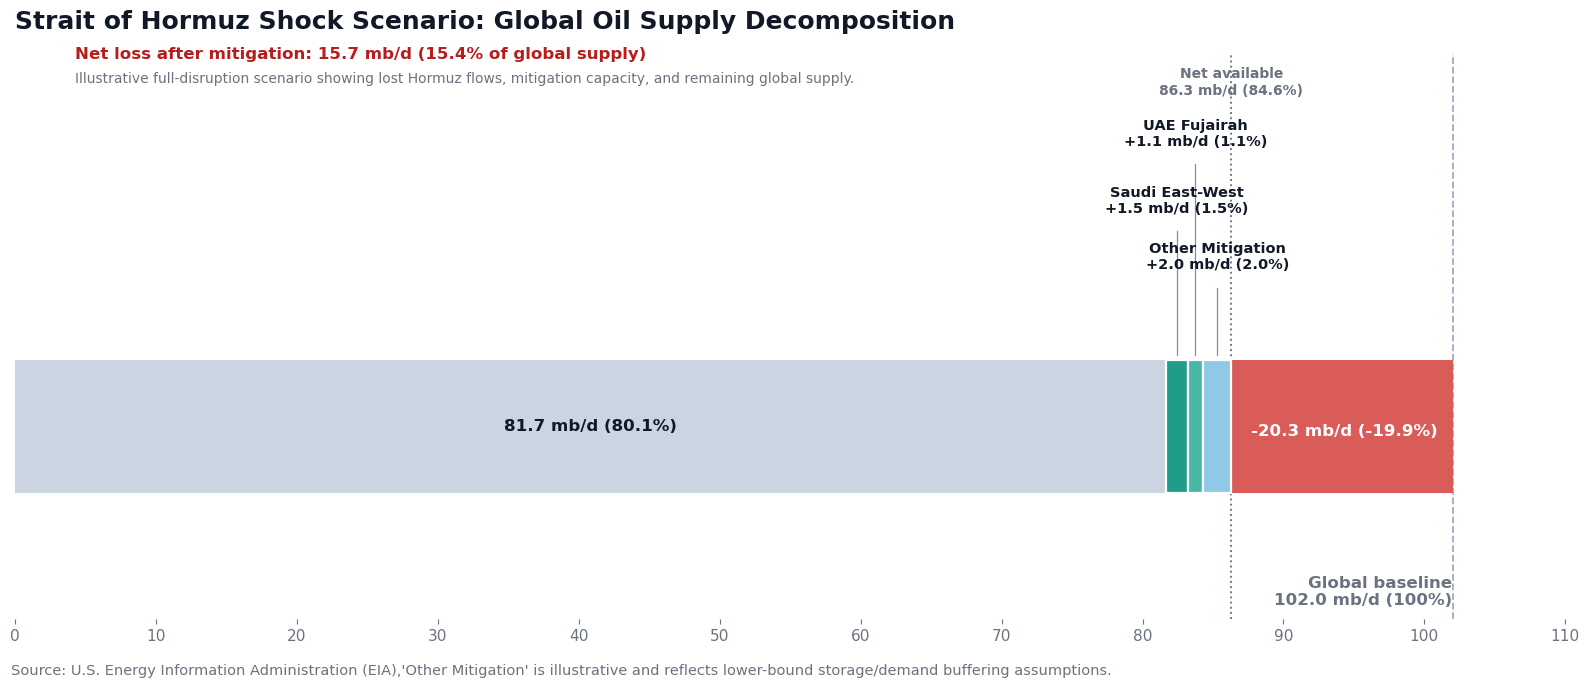

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Load data
# =========================================================
df = pd.read_csv("shock_scenario.csv")

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

# Rename common variants if needed
rename_map = {
    "valuembd": "value_mbpd",
    "percentglobal_supply": "percent_global_supply",
    "percent_global_supply": "percent_global_supply"
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Check required columns
required_cols = ["step", "value_mbpd", "step_type", "notes"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}\nCurrent columns: {list(df.columns)}")

# =========================================================
# 2. Extract Values
# =========================================================
baseline = df.loc[df["step_type"] == "baseline", "value_mbpd"].iloc[0]
net_supply = df.loc[df["step_type"] == "total", "value_mbpd"].iloc[0]

shock_row = df[df["step_type"] == "shock"].iloc[0]
mitigation_rows = df[df["step_type"] == "mitigation"].copy().reset_index(drop=True)

shock_abs = abs(shock_row["value_mbpd"])
remaining_after_shock = baseline - shock_abs
net_loss = baseline - net_supply
net_loss_pct = (net_loss / baseline) * 100
remaining_pct = (remaining_after_shock / baseline) * 100
net_supply_pct = (net_supply / baseline) * 100

# =========================================================
# 3. Style
# =========================================================
bg = "#ffffff"          
fg = "#111827"          # main text
muted = "#6b7280"       # secondary text
grid = "#d7dee8"       # subtle grid

remain_color = "#cbd5e1"    # soft slate
shock_color = "#d95c59"     # muted red
mitigation_colors = ["#1f9d8a", "#48b8a6", "#8ecae6", "#b6dceb"]

plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(16, 8), facecolor=bg)
ax.set_facecolor(bg)

# =========================================================
# 4. Main Bar
# =========================================================
y = 0
main_h = 0.52
mit_h = 0.52   # same height so mitigation doesn't look too short

# Remaining supply after shock
ax.barh(
    y, remaining_after_shock,
    left=0,
    height=main_h,
    color=remain_color,
    edgecolor="none",
    zorder=1
)

# Shock segment
ax.barh(
    y, shock_abs,
    left=remaining_after_shock,
    height=main_h,
    color=shock_color,
    edgecolor="none",
    zorder=1
)

# =========================================================
# 5. Mitigation Segments
# =========================================================
mit_left = remaining_after_shock
label_y_positions = [0.82, 1.08, 0.60, 1.02]

for i, row in mitigation_rows.iterrows():
    val = row["value_mbpd"]
    step = row["step"]
    color = mitigation_colors[i % len(mitigation_colors)]
    pct = (val / baseline) * 100
    x_center = mit_left + val / 2
    y_text = label_y_positions[i % len(label_y_positions)]

    # mitigation bars: full height, outlined for clarity
    ax.barh(
        y, val,
        left=mit_left,
        height=mit_h,
        color=color,
        edgecolor=bg,
        linewidth=1.6,
        zorder=3
    )

    # clean short names
    short_name = (
        step.replace(" Available Bypass", "")
            .replace("Other Mitigation (Illustrative: Storage + Demand)", "Other Mitigation")
            .replace("Other Mitigation (Storage + Demand)", "Other Mitigation")
    )

    # leader line
    ax.plot(
        [x_center, x_center],
        [main_h / 2 + 0.02, y_text - 0.06],
        color=muted,
        lw=0.9,
        alpha=0.8,
        zorder=4
    )

    ax.text(
        x_center,
        y_text,
        f"{short_name}\n+{val:.1f} mb/d ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10.5,
        color=fg,
        fontweight="bold",
        zorder=5
    )

    mit_left += val

# =========================================================
# 6. Core labels
# =========================================================
# Remaining after shock label: add percent
ax.text(
    remaining_after_shock / 2,
    y,
    f"{remaining_after_shock:.1f} mb/d ({remaining_pct:.1f}%)",
    ha="center",
    va="center",
    fontsize=12,
    color=fg,
    fontweight="bold",
    zorder=5
)

# Shock label inside red block

x_offset = 0.62   
y_offset = -0.05

ax.text(
    remaining_after_shock + shock_abs * x_offset,
    y + y_offset,
    f"-{shock_abs:.1f} mb/d (-{shock_abs / baseline * 100:.1f}%)",
    ha="center",
    va="bottom",
    fontsize=12,
    color="white",
    fontweight="bold",
    zorder=5
)

# Baseline marker
ax.axvline(baseline, color="#94a3b8", linestyle="--", lw=1.3, alpha=0.9, zorder=0)
ax.text(
    baseline,
    -0.58,
    f"Global baseline\n{baseline:.1f} mb/d (100%)",
    ha="right",
    va="top",
    fontsize=12,
    color=muted,
    fontweight="bold"
)

# Net available marker
ax.axvline(net_supply, color="#64748b", linestyle=":", lw=1.4, alpha=0.95, zorder=0)
ax.text(
    net_supply,
    1.28,
    f"Net available\n{net_supply:.1f} mb/d ({net_supply_pct:.1f}%)",
    ha="center",
    va="bottom",
    fontsize=10,
    color=muted,
    fontweight="bold"
)

# =========================================================
# 7. Titles/Header
# =========================================================
ax.set_title(
    "Strait of Hormuz Shock Scenario: Global Oil Supply Decomposition",
    loc="left",
    fontsize=18,
    color=fg,
    fontweight="bold",
    pad=18
)

fig.text(
    0.05, 0.80,
    "Illustrative full-disruption scenario showing lost Hormuz flows, mitigation capacity, and remaining global supply.",
    fontsize=10,
    color=muted
)

fig.text(
    0.05, 0.83,
    f"Net loss after mitigation: {net_loss:.1f} mb/d ({net_loss_pct:.1f}% of global supply)",
    fontsize=12,
    color="#b91c1c",
    fontweight="bold"
)

# =========================================================
# 8. Axes format
# =========================================================
ax.set_xlim(0, baseline + 8)
ax.set_ylim(-0.75, 1.45)

ax.set_yticks([])
ax.set_xticks(range(0, 111, 10))
ax.tick_params(axis="x", colors=muted, labelsize=11)

for spine in ax.spines.values():
    spine.set_visible(False)


# =========================================================
# 9. Footnote
# =========================================================
fig.text(
    0.01, 0.06,
    "Source: U.S. Energy Information Administration (EIA),'Other Mitigation' is illustrative and reflects lower-bound storage/demand buffering assumptions.",
    fontsize=10.5,
    color=muted
)

plt.tight_layout(rect=[0, 0.08, 1, 0.91])
plt.savefig("Strait_of_Hormuz_Shock Scenario_Global_Oil_Supply_Decomposition.png", dpi=300, bbox_inches="tight")
plt.show()



A full disruption of oil flows through the Strait of Hormuz would remove approximately 20.3 mb/d, equivalent to about one-fifth (~19.9%) of global oil supply. While mitigation mechanisms exist, their capacity is limited relative to the scale of the shock. Saudi Arabia provides the largest alternative route through its East-West pipeline (around 1.5 mb/d), followed by the UAE’s Fujairah bypass (approximately 1.1 mb/d), with additional buffering from storage releases and demand adjustments contributing roughly 2.0 mb/d. 

In total, these measures recover only about 4.6 mb/d, leaving a substantial portion of the disruption unaddressed. As a result, global oil supply would fall to approximately 86.3 mb/d, implying a net loss of around 15.7 mb/d, or roughly 15% of global supply. This gap underscores the limited flexibility of global oil infrastructure in the short term and highlights the potential for severe market dislocation in the event of a sustained disruption.

---

#### Main Takeaway

Oil flows through the Strait of Hormuz originate from a small group of Gulf exporters—led by Saudi Arabia, Iraq, and the UAE—and are primarily destined for Asia, with China, India, Japan, and South Korea as the largest recipients. This creates a highly concentrated flow structure centered on a single maritime chokepoint.

As a result, exposure to Hormuz-dependent supply is uneven and heavily concentrated in Asia, while countries such as the United States and much of Europe remain relatively insulated due to diversified supply sources.

In the event of a disruption, the global oil system has limited capacity to offset the shock. Even after accounting for available mitigation, a significant supply gap remains, implying a severe reduction in global oil availability and heightened risk of market disruption.

<div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px;">
Ultimately, the Strait of Hormuz is not just a transit route—it is a critical point of vulnerability in the global energy system, where localized disruptions can have outsized global consequences.
</div>


In [4]:
# convert to html

from nbconvert import HTMLExporter
import nbformat

# Load the notebook file (.ipynb)
with open("Strait_of_Hormuz_Data_Story.ipynb", "r", encoding="utf-8") as f:
    notebook_content = nbformat.read(f, as_version=4)

# Initialize HTMLExporter with the `no-input` option to hide code
html_exporter = HTMLExporter()
html_exporter.exclude_input = True  # This hides the code cells

# Convert the notebook to HTML
body, resources = html_exporter.from_notebook_node(notebook_content)

# Save the HTML output
with open("output_without_code_2.html", "w", encoding="utf-8") as f:
    f.write(body)

print("Notebook has been exported to HTML without code.")

Notebook has been exported to HTML without code.


*This notebook was developed as part of a **data visualization coursework** project to demonstrate how multiple visualization techniques can be combined into a coherent data story.*

*By integrating a **network visualization**, **choropleth map**, and **shock scenario analysis**, the project illustrates both the structure of global oil trade and the potential consequences of disruptions to one of the world's most critical energy chokepoints.*